In [13]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# df = pd.read_csv('C:\\Rekha\\InputFiles\\CaseStudy_1\\covid_vaccine_statewise.csv')
# df.head()
# Read it directly from google drive
url = "https://drive.google.com/file/d/1jAJ2KbSl9_DOAzLxdxDe6WdOmW2FERoZ/view?usp=sharing"
file_id=url.split('/')[-2]
dwn_url='https://drive.google.com/uc?id=' + file_id
df = pd.read_csv(dwn_url)
df.head(5)


,Updated On,State,Total Doses Administered,Sessions,Sites,First Dose Administered,Second Dose Administered,Male (Doses Administered),Female (Doses Administered),Transgender (Doses Administered),...,18-44 Years (Doses Administered),45-60 Years (Doses Administered),60+ Years (Doses Administered),18-44 Years(Individuals Vaccinated),45-60 Years(Individuals Vaccinated),60+ Years(Individuals Vaccinated),Male(Individuals Vaccinated),Female(Individuals Vaccinated),Transgender(Individuals Vaccinated),Total Individuals Vaccinated
0,16/01/2021,India,48276.0,3455.0,2957.0,48276.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23757.0,24517.0,2.0,48276.0
1,17/01/2021,India,58604.0,8532.0,4954.0,58604.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27348.0,31252.0,4.0,58604.0
2,18/01/2021,India,99449.0,13611.0,6583.0,99449.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41361.0,58083.0,5.0,99449.0
3,19/01/2021,India,195525.0,17855.0,7951.0,195525.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,81901.0,113613.0,11.0,195525.0
4,20/01/2021,India,251280.0,25472.0,10504.0,251280.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,98111.0,153145.0,24.0,251280.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7845 entries, 0 to 7844
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Updated On                           7845 non-null   datetime64[ns]
 1   State                                7845 non-null   object        
 2   Total Doses Administered             7621 non-null   float64       
 3   Sessions                             7621 non-null   float64       
 4    Sites                               7621 non-null   float64       
 5   First Dose Administered              7621 non-null   float64       
 6   Second Dose Administered             7621 non-null   float64       
 7   Male (Doses Administered)            7461 non-null   float64       
 8   Female (Doses Administered)          7461 non-null   float64       
 9   Transgender (Doses Administered)     7461 non-null   float64       
 10   Covaxin (Do

In [9]:
df['Updated On'] = pd.to_datetime(df['Updated On'], format="%d/%m/%Y")

In [23]:
x=df['State'].unique()
x.sort()


In [32]:
df_1 = df[['State','Total Doses Administered']]
df_1 = df_1.groupby(['State']).max().reset_index() # reset_index convert the output to table
df_1 = df_1.sort_values('Total Doses Administered',ascending=False)[1:10]
df_1

,State,Total Doses Administered
34,Uttar Pradesh,54447724.0
21,Maharashtra,47153366.0
10,Gujarat,37152375.0
20,Madhya Pradesh,35456676.0
29,Rajasthan,35383662.0
16,Karnataka,33280543.0
36,West Bengal,32390378.0
4,Bihar,27834939.0
31,Tamil Nadu,25522708.0


<AxesSubplot:xlabel='State', ylabel='Total Doses Administered'>

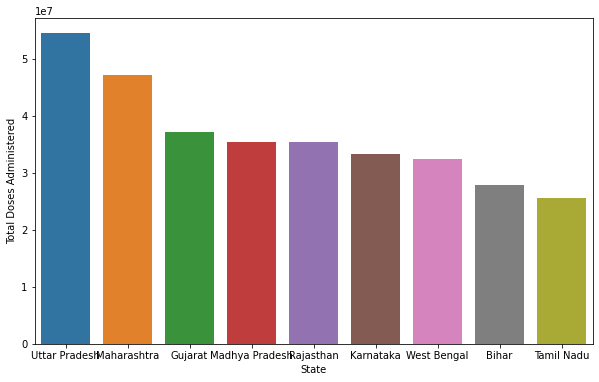

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(x = "State", y= 'Total Doses Administered',data=df_1)

#### Vaccination admistered state wise (Top 6 states)

In [56]:
state_list = df_1["State"][:6].tolist()
state_list
cond = df["State"].isin(state_list)
df_2= df[cond]


<AxesSubplot:xlabel='Updated On', ylabel='Total Doses Administered'>

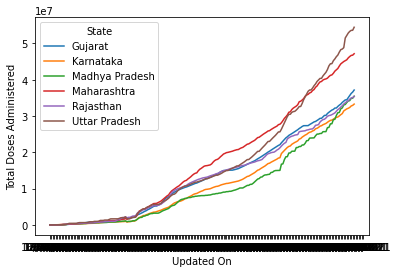

In [57]:
sns.lineplot(x="Updated On",y ='Total Doses Administered',data = df_2,hue='State' )
